# Unsupervised Hypersphere Fitting Algorithm

This notebook implements and adapts ideas from A classification method based on a cloud of spheres [ ]. The original work proposes constructing spherical regions to define decision boundaries between classes. In this project, the method is adapted for unsupervised anomaly detection using MVTec AD and DINOv2 embeddings.

The original paper differs from this setting in two important ways:

- Supervised boundary construction: 
The original algorithm uses both positive and negative classes when forming spheres. In this project, only normal training samples are available, so the sphere boundaries must be estimated without defective samples. To address this, candidate regions are initialised from local KNN density and then expanded using a constrained growth step.

- Connected manifold assumption:
The original method assumes that the data lie on a shared manifold and encourages connected spherical regions. This assumption is less appropriate here because DINOv2 produces 768-dimensional general-purpose embeddings. A single object category may occupy several disconnected regions in this embedding space. Therefore, the adapted algorithm does not require spheroids to be connected.

- Exclusive embedding assignment
The adapted algorithm enforces that each normal training embedding belongs to exactly one spheroid. During the growth stage, candidate regions are iteratively cleaned to ensure that previously assigned embeddings are not incorporated into newly generated spheroids. While geometric overlap between spheroids is permitted, overlap in embedding ownership is not. This results in a unique partitioning of the normal embedding space while still allowing neighbouring regions to share empty areas of the embedding space.

In [26]:
import os
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import joblib

import faiss
import sqlite3

from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, precision_recall_curve
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import plotly.graph_objects as go

ROOT = Path.cwd().parents[1]

EMBED_PATH = ROOT / "data/embeddings/base_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

IMAGE_DIR = ROOT / "images/ellipsoid" / EMBED_NAME
CACHE_DIR = ROOT / "data/cache" / EMBED_NAME
RESULTS_DIR = ROOT / "data/results" / EMBED_NAME

In [27]:
os.makedirs(IMAGE_DIR, exist_ok=True)

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [28]:
embeds = torch.load(EMBED_PATH, weights_only=False)
cls_tokens = embeds["cls_tokens"]

In [29]:
conn = sqlite3.connect(ROOT / "data/sql/metadata.db")

meta = pd.read_sql_query("SELECT * FROM meta", conn)
categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()

conn.close()

In [30]:
def load_or_compute(path, model_path, fn):
    if path.exists() and model_path.exists():
        print("Loading ", path)
        return np.load(path), joblib.load(model_path)
    
    print("Computing ", path)
    coords, model = fn()
    
    np.save(path, coords)
    joblib.dump(model, model_path)
    return coords, model

In [31]:
def compute_pca():
    pca = PCA(n_components=2)
    coords = pca.fit_transform(cls_tokens)
    return coords, pca

## How does Mahlanobis fit to the data

This section visualises how a global Mahalanobis ellipsoid fits the normal training embeddings and uses it as a baseline for comparison with the proposed hypersphere fitting algorithm.

The objective is not to evaluate the performance of Mahalanobis, but rather to understand the assumptions it makes about the embedding space. In particular, Mahalanobis models the normal distribution as a single ellipsoidal region defined by the global centroid and covariance matrix. The following visualisations illustrate how well this assumption represents the underlying embedding distribution before introducing the proposed multi-region fitting approach.

Loading  c:\projects\bursary\data\cache\base_embeds\cls_pca.npy


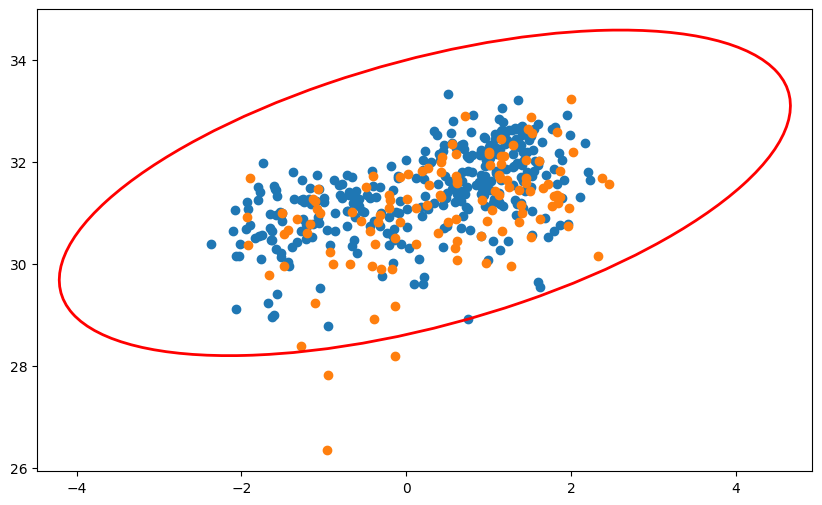

In [32]:
img_dir = IMAGE_DIR / "mahlanobis_fit" 
os.makedirs(img_dir, exist_ok=True)

category = "screw"

train_mask = meta["split"] == "train"
train_meta = meta[train_mask]
test_meta = meta[~train_mask]

train_cat_mask = train_meta["category"] == category

good_test_cat_mask = (test_meta["category"] == category) & (test_meta["type"] == "good")
defect_test_cat_mask = (test_meta["category"] == category) & (test_meta["type"] != "good")

pca_2d, pca = load_or_compute(CACHE_DIR / "cls_pca.npy", CACHE_DIR / "pca.joblib", compute_pca)
pca_train = pca_2d[train_mask]
pca_test = pca_2d[~train_mask]

train_2d = pca_train[train_cat_mask]
test_2d = pca_test[defect_test_cat_mask]

center = train_2d.mean(axis=0)

cov = np.cov(train_2d.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = np.linalg.pinv(cov)

diff = train_2d - center
d2 = np.einsum("ij, jk, ik->i", diff, cov_inv, diff)

ch2 = d2.max()

eigvals, eigvecs = np.linalg.eigh(cov)

order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

width = 2 * np.sqrt(eigvals[0] * ch2)
height = 2 * np.sqrt(eigvals[1] * ch2)

angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=train_2d[:, 0], y=train_2d[:, 1])
ax.scatter(x=test_2d[:, 0], y=test_2d[:, 1])

ellipse = Ellipse(
    xy=center,
    width=width,
    height=height,
    angle=angle,
    edgecolor="red",
    facecolor="none",
    linewidth=2
)

ax.add_patch(ellipse)
plt.savefig(f"{img_dir}/{category}.svg")
plt.show()

## Choosing a Value for K

The first step of the proposed algorithm is identifying the densest local region of the normal embedding space. This is achieved using a K-nearest neighbours (KNN) search, where the embedding with the smallest average distance to its neighbours is selected as the initial sphere centre.

Selecting an appropriate value for K is important. If K is too small, the initial neighbourhood becomes overly sensitive to local noise and may fail to capture a representative region. Conversely, if K is too large, the neighbourhood becomes overly broad, increasing the likelihood of creating a hypersphere that encompasses a significant proportion of the embedding space.

As each MVTec AD category contains a different number of normal training samples, selecting a fixed value of K would not scale consistently across categories. Instead, K is defined as a percentage of the available training embeddings. Three candidate values (2.5%, 5%, and 10%) are visually compared to determine a suitable compromise between capturing a dense local neighbourhood while avoiding an overly large initial region.

Cat length:  320
frac: 0.025
K: 8
most compact idx: 72
avg KNN dist: 51.533062
frac: 0.05
K: 16
most compact idx: 72
avg KNN dist: 59.03626
frac: 0.1
K: 32
most compact idx: 72
avg KNN dist: 73.150925


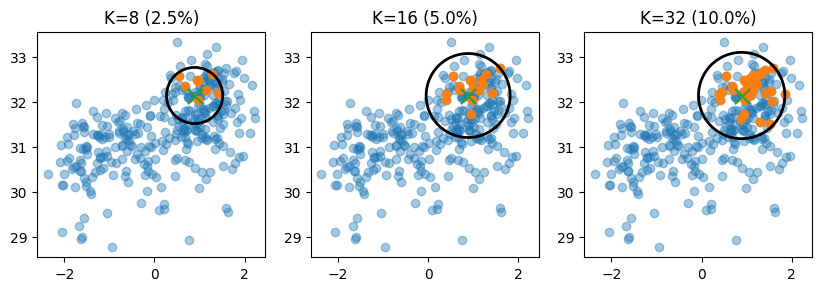

In [33]:
img_dir = IMAGE_DIR / "k_rate"
os.makedirs(img_dir, exist_ok=True)

train_emb = cls_tokens[train_mask]
cat_emb = train_emb[train_cat_mask]
pca_cat = pca_train[train_cat_mask]

print("Cat length: ", len(cat_emb))

fig, axes = plt.subplots(1, 3, figsize=(10, 6))

for i, frac in enumerate([0.025, 0.05, 0.10]):
    K = max(2, int(frac * len(cat_emb)))

    index = faiss.IndexFlatL2(cat_emb.shape[1])
    index.add(cat_emb.astype("float32"))

    D, I = index.search(
        cat_emb.astype("float32"),
        k=K+1 # Nearest is itself
    )

    D = D[:, 1:]    # Remove self
    I = I[:, 1:]

    avg_knn = D.mean(axis=1)

    most_compact_idx = avg_knn.argmin()
    neighbours = I[most_compact_idx]
    
    center_2d = pca_cat[most_compact_idx]

    neighbours_2d = pca_cat[neighbours]
    radius_2d = np.linalg.norm(neighbours_2d - center_2d, axis=1).max()

    ax = axes[i]
    ax.scatter(pca_cat[:, 0], pca_cat[:, 1], alpha=0.4)
    ax.scatter(neighbours_2d[:, 0], neighbours_2d[:, 1], alpha=0.9)
    ax.scatter(center_2d[0], center_2d[1], marker="x", s=120)

    circle = Circle(
        center_2d,
        radius_2d,
        fill=False,
        linewidth=2
    )

    ax.add_patch(circle)
    ax.set_title(f"K={K} ({frac*100:.1f}%)")
    ax.set_aspect("equal", adjustable="box")

    print("frac:", frac)
    print("K:", K)
    print("most compact idx:", most_compact_idx)
    print("avg KNN dist:", avg_knn[most_compact_idx])

plt.savefig(f"{img_dir}/{category}.svg")
plt.show()


The value in the end selected was 5% of the available training embeddings. Visually, this provided the best balance between capturing a representative local neighbourhood while avoiding an initial hypersphere that encompassed an excessively large region of the embedding space.

Although this percentage is unlikely to be optimal for every category, as the structure of the embedding space varies between object classes, it provides a consistent and scalable initialisation strategy across the MVTec AD dataset. Furthermore, the subsequent growth stage allows the hypersphere to adapt to the local embedding distribution, reducing the sensitivity of the overall algorithm to the initial choice of K.

## Growth Rate for the Hyperspheres

Although the initial KNN neighbourhood provides a suitable starting point, the choice of K remains arbitrary and should not solely determine the size of a hypersphere. To reduce the dependence on this initial neighbourhood, a growth stage is introduced.

Starting from the initial KNN region, the hypersphere is iteratively expanded by a small growth factor. After each expansion, any newly enclosed embeddings are incorporated into the region and the hypersphere is recalculated using the updated centroid and radius. This process continues until no additional embeddings can be added.

The purpose of the growth stage is to allow each hypersphere to adapt naturally to the local structure of the embedding space rather than being constrained by the initial KNN selection. In particular, it reduces the likelihood of producing a large number of singleton or very small hyperspheres, allowing neighbouring embeddings that belong to the same local region to be grouped together.

Cat length:  320
RUN:  1
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (17, 2)
Growth:  1.0
RUN:  1
RUN:  2
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (18, 2)
Growth:  1.025
RUN:  1
RUN:  2
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (20, 2)
Growth:  1.05
RUN:  1
RUN:  2
RUN:  3
RUN:  4
RUN:  5
RUN:  6
RUN:  7
RUN:  8
RUN:  9
RUN:  10
RUN:  11
RUN:  12
RUN:  13
RUN:  14
RUN:  15
RUN:  16
RUN:  17
RUN:  18
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (320, 2)
Growth:  1.1


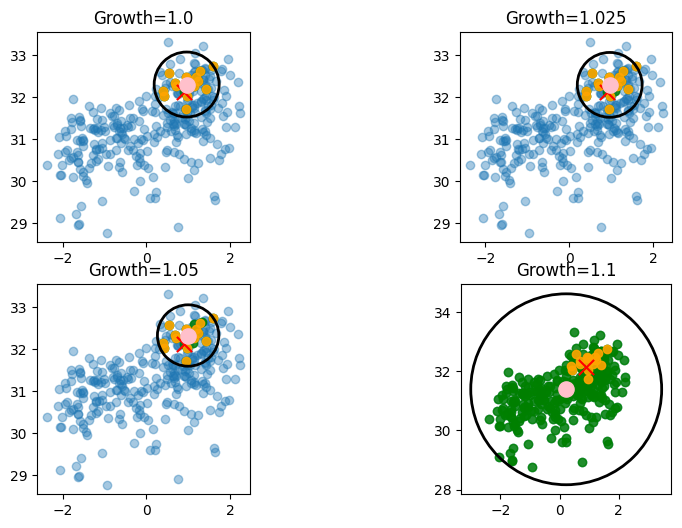

In [34]:
img_dir = IMAGE_DIR / "growth_rate"
os.makedirs(img_dir, exist_ok=True)

train_emb = cls_tokens[train_mask]
cat_emb = train_emb[train_cat_mask]
pca_cat = pca_train[train_cat_mask]

print("Cat length: ", len(cat_emb))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

K = max(2, int(0.05 * len(cat_emb)))

index = faiss.IndexFlatL2(cat_emb.shape[1])
index.add(cat_emb.astype("float32"))

D, I = index.search(
    cat_emb.astype("float32"),
    k=K+1 # Nearest is itself
)

D = D[:, 1:]    # Remove self
I = I[:, 1:]

avg_knn = D.mean(axis=1)

most_compact_idx = avg_knn.argmin()
neighbours = I[most_compact_idx]

center = cat_emb[most_compact_idx]
radius = np.sqrt(D[most_compact_idx, -1])

distances = np.linalg.norm(cat_emb - center, axis=1)

covered_mask = distances <= radius
covered_idx = np.where(covered_mask)[0]


for i, growth in enumerate([1.00, 1.025, 1.05, 1.10]):
    ax = axes[i]

    j = 1
    while True:
        print("RUN: ", j)
        centroid = cat_emb[covered_idx].mean(axis=0)

        radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()
        radius *= growth

        distances = np.linalg.norm(cat_emb - centroid, axis=1)
        new_covered_idx = np.where(distances <= radius)[0]

        if np.array_equal(np.sort(new_covered_idx), np.sort(covered_idx)):
            break

        covered_idx = new_covered_idx
        j += 1

    centroid = cat_emb[covered_idx].mean(axis=0)
    radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()

    centroid_2d = pca.transform(centroid.reshape(1, -1))[0]
    center_2d = pca_cat[most_compact_idx]

    neighbours_2d = pca_cat[neighbours]
    covered_2d = pca_cat[covered_idx]

    radius_2d = np.linalg.norm(covered_2d - centroid_2d, axis=1).max()

    ax.scatter(pca_cat[:, 0], pca_cat[:, 1], alpha=0.4)
    ax.scatter(covered_2d[:, 0], covered_2d[:, 1], alpha=0.8, color="green")
    ax.scatter(neighbours_2d[:, 0], neighbours_2d[:, 1], alpha=0.9, color="orange")
    ax.scatter(center_2d[0], center_2d[1], marker="x", s=120, color="red")
    ax.scatter(centroid_2d[0], centroid_2d[1], marker="o", s=120, color="pink")

    circle = Circle(
        centroid_2d,
        radius_2d,
        fill=False,
        linewidth=2
    )

    ax.add_patch(circle)
    ax.set_title(f"Growth={growth}")
    ax.set_aspect("equal", adjustable="box")

    print("K:", K)

    print("Neighbours Shape: ", neighbours_2d.shape)
    print("Covered Shape: ", covered_2d.shape)

    print("Growth: ", growth)

plt.savefig(f"{img_dir}/{category}.svg")
plt.show()

A growth rate of 5% was selected as the most suitable value. This provided enough expansion to include additional nearby embeddings from the same local neighbourhood, while avoiding excessive growth. A smaller growth rate of 2.5% produced little change from the initial KNN region, whereas a larger growth rate of 10% caused the hypersphere to expand too broadly, creating a catch-all region. This behaviour would reduce the benefit of the proposed method, as the resulting hypersphere would begin to resemble a global centroid-based model rather than a local region-based representation.

#

In [ ]:
def clean_candidate(covered_idx, cat_emb, uncovered_mask):
    """
    Iteratively emoved embeddings form a candidate hypersphere until it statisifes the
    exclusive embedding embedding assignment constraint

    Starting from a candiate set of embeddings, the function repeatedly computed the
    centroid and radius of the hyphersphere. If the resulting hyphersphere contains embeddings that 
    have been assinged to previous hyperspheres, the embedding contributing most to the current radius
    is removed and the hypersphere is recomputed. This process continues until no previously assinged 
    embedings lie within the hypersphere or onbly a single embedding remains

    Parameters
    ----------
    covered_idx : ndarray
        Indices of embeddings current assigned to the candidate hypersphere

    cat_emb : ndarray
        Embedding matrix of the current object category

    uncovered_mask : ndarray
        Boolean mask indicating which embeddings have not yet been assigned
        to a hypersphere

    Returns
    -------
    covered_idx : ndarray
        Indices of the cleaned hypersphere

    centroid : ndarray
        Centroid of the final hypersphere
    
    radius : float
        Radius of the final hypersphere. (Singleton spheres have radius 0)
    """

    while len(covered_idx) > 1:
        centroid = cat_emb[covered_idx].mean(axis=0)

        d_self = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1)
        radius = d_self.max()

        d_all = np.linalg.norm(cat_emb - centroid, axis=1)
        inside_all = np.where(d_all <= radius)[0]

        shared_count = np.sum(~uncovered_mask[inside_all])

        if shared_count == 0:
            return covered_idx, centroid, radius

        # remove point causing the current sphere to stretch the most
        worst_local = d_self.argmax()
        covered_idx = np.delete(covered_idx, worst_local)

    centroid = cat_emb[covered_idx]
    radius = 0.0 

    return covered_idx, centroid, radius

In [36]:
uncovered_mask = np.ones(len(cat_emb), dtype=bool)
spheres = []

K_frac = 0.05

start_growth = 1.05
min_growth = 1

while uncovered_mask.any():
    uncovered_idx = np.where(uncovered_mask)[0]
    uncovered_emb = cat_emb[uncovered_idx].astype("float32")

    K = max(2, int(K_frac * len(uncovered_idx)))
    K = min(K, len(uncovered_idx) - 1)

    growth = max(min_growth, start_growth - 0.0025 * len(spheres))
    if K < 1:
        covered_idx = uncovered_idx
        centroid = cat_emb[covered_idx].mean(axis=0)
        radius = 0.0
    else:
        index = faiss.IndexFlatL2(uncovered_emb.shape[1])
        index.add(uncovered_emb)

        D, I = index.search(uncovered_emb.astype("float32"), k=K+1) # +1 as nearest is itself 

        D = D[:, 1:]    # Remove self
        I = I[:, 1:]

        avg_knn = D.mean(axis=1)

        local_compact  = avg_knn.argmin()
        neighbours_local = I[local_compact]

        full_covered_idx = uncovered_idx[np.r_[local_compact, neighbours_local]]

        covered_idx, centroid, radius = clean_candidate(
            full_covered_idx,
            cat_emb,
            uncovered_mask,
            min_points=1
        )

        if len(full_covered_idx) == len(covered_idx):
            while True:
                old_covered_idx = covered_idx.copy()
                
                search_radius = radius * growth
                distances = np.linalg.norm(cat_emb - centroid, axis=1)

                candidate_idx = np.where(distances <= search_radius)[0]
                full_new_covered_idx = candidate_idx[uncovered_mask[candidate_idx]]
                
                new_covered_idx, new_centroid, new_radius = clean_candidate(full_new_covered_idx, cat_emb, uncovered_mask, min_points=len(old_covered_idx)) 

                if len(new_covered_idx) > len(old_covered_idx):
                    covered_idx = new_covered_idx
                    centroid = new_centroid
                    radius = new_radius
                else:
                    break

            centroid = cat_emb[covered_idx].mean(axis=0)
            radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()

    spheres.append({
        "center": centroid,
        "radius": radius,
        "covered_idx": covered_idx
    })

    uncovered_mask[covered_idx] = False

spheres_df = pd.DataFrame(spheres)
spheres_df

,center,radius,covered_idx
0,"[-0.8297928, -0.42666012, -4.332676, 0.6239084...",7.389969,"[9, 14, 42, 44, 48, 52, 72, 94, 103, 141, 216,..."
1,"[0.49987584, -0.1425552, -4.717271, 1.6784661,...",8.804199,"[20, 24, 25, 62, 86, 89, 114, 118, 143, 159, 1..."
2,"[-0.70402825, 0.45372054, -2.6601279, 0.566990...",9.189863,"[12, 37, 40, 61, 67, 71, 111, 120, 131, 142, 1..."
3,"[-1.4256153, 0.2902548, -3.0739627, 1.669667, ...",8.985531,"[190, 209, 151, 144, 236, 257, 239, 282, 58, 8..."
4,"[0.2205792, -0.029556803, -4.5622387, 0.916618...",11.856756,"[1, 3, 16, 19, 27, 29, 34, 51, 56, 63, 78, 81,..."
5,"[-0.20566511, -0.4071494, -3.9430745, 0.341515...",9.347671,"[5, 28, 35, 80, 95, 98, 102, 104, 125, 139, 18..."
6,"[-0.21677311, -0.49954948, -4.1278954, 0.64313...",7.802741,"[150, 129, 170, 10, 69, 138, 192, 206, 227, 13]"
7,"[0.025590172, -0.30438966, -4.107446, 0.101233...",6.288072,"[22, 121, 65, 201, 26, 133]"
8,"[-0.43237203, -0.43448672, -4.5473022, 1.38612...",6.810811,"[148, 108, 161, 60, 277, 275, 164]"
9,"[-0.11394278, -0.31851587, -4.1371903, 0.10339...",7.560016,"[88, 54, 175, 59, 203, 313, 6, 167]"


In [37]:
overlaps = []

for i, j in combinations(range(len(spheres)), 2):
    c1 = spheres[i]["center"]
    c2 = spheres[j]["center"]

    r1 = spheres[i]["radius"]
    r2 = spheres[j]["radius"]

    centre_dist = np.linalg.norm(c1 - c2)
    overlap_amount = (r1+r2) - centre_dist
    
    dist_to_c1 = np.linalg.norm(cat_emb[spheres[j]["covered_idx"]] - c1, axis=1) 
    dist_to_c2 = np.linalg.norm(cat_emb[spheres[i]["covered_idx"]] - c2, axis=1) 

    c1_overlap_count = np.sum(dist_to_c1 <= r1)
    c2_overlap_count = np.sum(dist_to_c2 <= r2)

    overlaps.append({
        "sphere_i": i,
        "sphere_j": j,
        "centre_dist": centre_dist,
        "add_radii": r1 + r2,
        "overlap": overlap_amount > 0,
        "overlap_amount": max(0, overlap_amount),
        "j_points_inside_i": c1_overlap_count,
        "i_points_inside_j": c2_overlap_count
    })

overlap_df = pd.DataFrame(overlaps)

overlap_df.to_csv(RESULTS_DIR / "sphere_overlaps.csv")
overlap_df

,sphere_i,sphere_j,centre_dist,add_radii,overlap,overlap_amount,j_points_inside_i,i_points_inside_j
0,0,1,16.673229,16.194168,False,0.000000,0,0
1,0,2,17.587193,16.579832,False,0.000000,0,0
2,0,3,15.394529,16.375500,True,0.980970,0,0
3,0,4,12.366000,19.246725,True,6.880725,0,0
4,0,5,9.724252,16.737640,True,7.013389,0,0
...,...,...,...,...,...,...,...,...
1480,51,53,26.195654,18.112675,False,0.000000,0,0
1481,51,54,20.442047,21.932087,True,1.490040,0,0
1482,52,53,25.270586,9.333305,False,0.000000,0,0
1483,52,54,19.036207,13.152717,False,0.000000,0,0


In [38]:
num_overlap = overlap_df["overlap"].sum()

num_overlap

np.int64(280)

In [39]:
overlapped_points = set()

for _, row in overlap_df.iterrows():
    i = int(row["sphere_i"])
    j = int(row["sphere_j"])

    # points owned by j that are inside i
    dist_j_to_i = np.linalg.norm(cat_emb[spheres[j]["covered_idx"]] - spheres[i]["center"], axis=1)
    overlapped_points.update(spheres[j]["covered_idx"][dist_j_to_i <= spheres[i]["radius"]])

    # points owned by i that are inside j
    dist_i_to_j = np.linalg.norm(cat_emb[spheres[i]["covered_idx"]] - spheres[j]["center"], axis=1)
    overlapped_points.update(spheres[i]["covered_idx"][dist_i_to_j <= spheres[j]["radius"]])

len(overlapped_points), len(overlapped_points) / len(cat_emb)

(0, 0.0)

In [40]:
def inside_any_count(X, spheres):
    inside_any = np.zeros(len(X), dtype=bool)
    inside_count = np.zeros(len(X), dtype=int)

    for s in spheres:
        d = np.linalg.norm(X - s["center"], axis=1)
        inside = d <= s["radius"]

        inside_any |= inside
        inside_count += inside

    return inside_any, inside_count

In [41]:
test_emb = cls_tokens[~train_mask]
defect_test_emb = test_emb[defect_test_cat_mask]
good_test_emb = test_emb[good_test_cat_mask]

good_any, good_counts = inside_any_count(good_test_emb, spheres)
defect_any, defect_counts = inside_any_count(defect_test_emb, spheres)

print("Good accepted:", good_any.sum(), "/", len(good_test_emb))
print("Defect accepted:", defect_any.sum(), "/", len(defect_test_emb))

print("\nGood multi-sphere:", np.sum(good_counts > 1))
print("Defect multi-sphere:", np.sum(defect_counts > 1))

Good accepted: 16 / 41
Defect accepted: 10 / 119

Good multi-sphere: 1
Defect multi-sphere: 0


In [42]:
X = np.vstack([good_test_emb, defect_test_emb])

# 0 = normal, 1 = defect
y_true = np.concatenate([
    np.zeros(len(good_test_emb)),
    np.ones(len(defect_test_emb))
])

scores = np.full(len(X), np.inf)

for s in spheres:
    d = np.linalg.norm(X - s["center"], axis=1)
    margin = d - s["radius"]      # <0 inside, >0 outside

    scores = np.minimum(scores, margin)

auroc = roc_auc_score(y_true, scores)

print("AUROC:", auroc)

AUROC: 0.7776183644189383


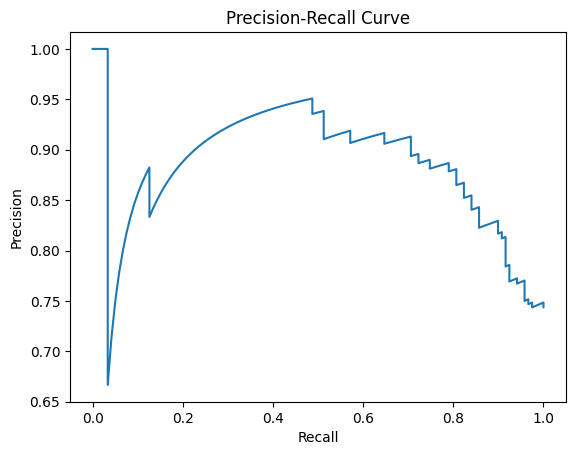

In [43]:
precision, recall, _ = precision_recall_curve(y_true, scores)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title("Precision-Recall Curve")

plt.show()

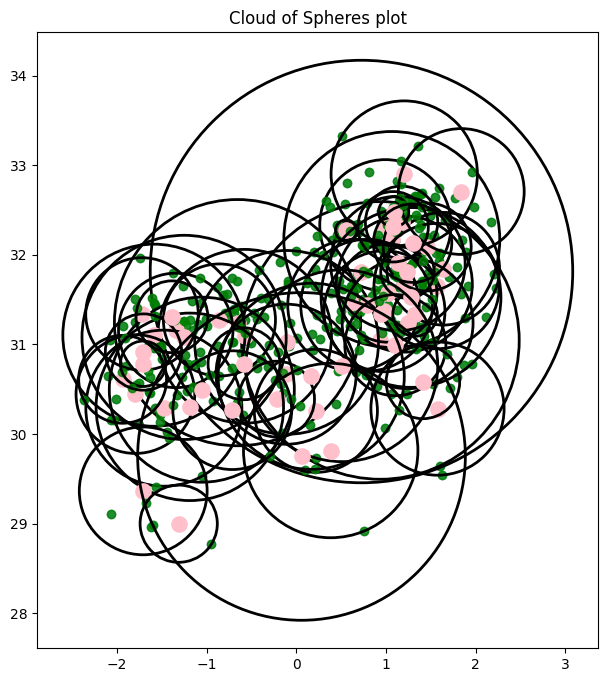

In [44]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.scatter(pca_cat[:, 0], pca_cat[:, 1], alpha=0.4)

for sphere in spheres:
    centroid = sphere["center"]
    covered_idx = sphere["covered_idx"]

    centroid_2d = pca.transform(centroid.reshape(1, -1))[0]
    covered_2d = pca_cat[covered_idx]

    radius_2d = np.linalg.norm(covered_2d - centroid_2d, axis=1).max()

    ax.scatter(covered_2d[:, 0], covered_2d[:, 1], alpha=0.8, color="green")
    ax.scatter(centroid_2d[0], centroid_2d[1], marker="o", s=120, color="pink")

    circle = Circle(
        centroid_2d,
        radius_2d,
        fill=False,
        linewidth=2
    )

    ax.add_patch(circle)

ax.set_title("Cloud of Spheres plot")
ax.set_aspect("equal", adjustable="box")

plt.show()

In [45]:
def sphere_surface(center, radius, resolution=20):
    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)

    x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

    return x, y, z

In [46]:
pca3 = PCA(n_components=3)
pca_3d = pca3.fit_transform(cls_tokens)

pca_train_3d = pca_3d[train_mask]
pca_cat_3d = pca_train_3d[train_cat_mask]

In [47]:
rng = np.random.default_rng(42)

colours = [
    f"rgb({r},{g},{b})"
    for r, g, b in rng.integers(30, 255, size=(len(spheres), 3))
]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=pca_cat_3d[:, 0],
    y=pca_cat_3d[:, 1],
    z=pca_cat_3d[:, 2],
    mode="markers",
    marker=dict(size=3, opacity=0.35),
    name="all screw train"
))

for i, s in enumerate(spheres):
    idx = s["covered_idx"]
    pts = pca_cat_3d[idx]

    center_3d = pts.mean(axis=0)
    radius_3d = np.linalg.norm(pts - center_3d).max()

    fig.add_trace(go.Scatter3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        mode="markers",
        marker=dict(size=4, color=colours[i]),
        name=f"sphere {i+1}",
        legendgroup=f"sphere{i}"
    ))

    fig.add_trace(go.Scatter3d(
        x=[center_3d[0]],
        y=[center_3d[1]],
        z=[center_3d[2]],
        mode="markers",
        marker=dict(size=7, symbol="x", color=colours[i]),
        name=f"center {i+1}",
        showlegend=False,
        legendgroup=f"sphere{i}"
    ))

    xs, ys, zs = sphere_surface(center_3d, radius_3d, resolution=20)

    fig.add_trace(go.Surface(
        x=xs,
        y=ys,
        z=zs,
        opacity=0.12,
        showscale=False,
        name=f"Boundary {i+1}",
        legendgroup=f"sphere{i}",
        showlegend=False
    ))

fig.update_layout(
    title="3D PCA multi-sphere assignment view",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ),
    width=900,
    height=750,
    updatemenus=[
    dict(
        type="buttons",
        buttons=[
            dict(
                label="Show All",
                method="update",
                args=[{"visible": [True] * len(fig.data)}]
            ),
            dict(
                label="Hide All",
                method="update",
                args=[{"visible": ["legendonly"] * len(fig.data)}]
            )
        ],
        x=1.15,
        y=0
    )
    ]
)

fig.show()